# Análisis Exploratorio del Dataset de Reseñas de productos y cuidado de la piel de Sephora

Este notebook explora el dataset crudo compuesto por el catálogo de productos de cosmética y las valoraciones de sus clientes. Identificaremos valores faltantes ocultos y propondremos un flujo de limpieza, integración de datos y análisis adaptado al contexto del proyecto..

## Configuración del Entorno y la Carga de Datos
Para garantizar la consistencia de este análisis, hemos configurado el entorno de trabajo para que sea dinámico. El código detecta automáticamente si se está ejecutando en la nube (**Google Colab**) o en un entorno local (**Visual Studio Code**), ajustando las rutas de los archivos.

**Primera validación de datos:** En esta etapa procedemos a cargar el catálogo principal (`product_info.csv`) y a unificar los múltiples archivos de comentarios de usuarios (`reviews_*.csv`) en un solo conjunto de datos. Al momento de cargar los archivos, aplicamos una limpieza inicial utilizando el parámetro `na_values`. Esto asegura que los strings vacíos o textos como "NULL" sean interpretados correctamente por Pandas como valores faltantes (`NaN`), preparándolos para nuestro análisis de nulos.

In [1]:
# Se importan las libterías necesarias para el análisis de datos y visualización
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Se ocultan advertencias para mantener el notebook limpio
warnings.filterwarnings('ignore') # Aveces, las advertencias pueden ser molestas

# Se configuran la visualizacion para que se vea más profesional
sns.set_theme(style='whitegrid') # Esto hace que tenga una cuadricula blanca de fondo
plt.rcParams['figure.figsize'] = (10, 6) # Esto ajusta el tamaño de los graficos

In [2]:
# Detectar si estamos en Google Colab y cargar los archivos de datos
try:
    import google.colab
    IN_COLAB = True # Si funciona, estamos en la nube (colab)
except ImportError:
    IN_COLAB = False # Si falla, estamos en local (VSC)

# Se configura la ruta de los archivos dependiendo del entorno
if IN_COLAB:
    print('Google Colab detectado. Sube TODOS los arhivos CSV al mismo tiempo (product_info.csv y las 5 reviews_*.csv).')
    from google.colab import files
    uploaded = files.upload() # Esto abre una ventana para seleccionar múltiples archivos
    if not uploaded:
        # Si se cancela la subida, se lanza un error
        raise FileNotFoundError('Debe subir los archivos en Colab antes de ejecutar el notebook.')
    ruta_base = '' # En Colab los archivos quedan en la raíz temporal
else:
    # Si no estamos en Colab, se asume que los archivos están en la ruta local
    ruta_base = '../data/raw/'

# Se definen los nombres exactos de los archivos
archivo_productos = 'product_info.csv'
archivos_reviews = [
    'reviews_0-250.csv',
    'reviews_250-500.csv',
    'reviews_500-750.csv',
    'reviews_750-1250.csv',
    'reviews_1250-end.csv'
]

print('\nIniciando la carga de los datos...')

# Se carga el catálogo de los productos
# El parametro 'na_values' transforma textos vacios o "NULL" en valores falatantes (NaN)
ruta_prod = f"{ruta_base}{archivo_productos}" if ruta_base else archivo_productos
df_productos = pd.read_csv(ruta_prod, na_values=['NULL', 'null', ''])
print(f'-> Productos cargados: {df_productos.shape[0]} filas.')

# Se cargan y se unen las 5 partes de reseñas
lista_reviews = []
for archivo in archivos_reviews:
    ruta_rev = f"{ruta_base}{archivo}" if ruta_base else archivo
    df_temp = pd.read_csv(ruta_rev, na_values=['NULL', 'null', ''])
    lista_reviews.append(df_temp)

df_reviews = pd.concat(lista_reviews, ignore_index=True)
print(f'-> Reseñas unidas: {df_reviews.shape[0]} filas en total.')

# Se unen las reseñas y productos en un solo DataFrame principal
# Usamos 'how="left"' para conservar todas las reseñas y traer la info del producto correspondiente
df_final = pd.merge(df_reviews, df_productos, on='product_id', how='left')

# Se hace una inspección rápida del dataset para entender su estructura
print('\n¡Unión completada exitosamente!')
print(f'Dimensiones del dataset final (df_final): {df_final.shape}') # Esto muestra cuantas filas y columnas tiene el dataset
df_final.head() # Esto muestra las primeras 5 filas del dataset para tener una idea de su contenido



Iniciando la carga de los datos...
-> Productos cargados: 8494 filas.
-> Reseñas unidas: 1094411 filas en total.

¡Unión completada exitosamente!
Dimensiones del dataset final (df_final): (1094411, 45)


,Unnamed: 0,author_id,rating_x,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,1,0,0,['Clean at Sephora'],Skincare,Cleansers,NaN,0,NaN,NaN
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0


## Diccionario de variables clave
Dado que hemos integrado el catálogo de productos con las reseñas de los usuarios, nuestro dataset ahora cuenta con información tanto del artículo como del perfil del cliente:

**Datos del Producto:**
- `product_id`: Identificador único del producto.
- `product_name`: Nombre comercial del producto.
- `brand_name`: Marca del producto.
- `price_usd`: Precio del producto en dólares.
- `ingredients`: Lista de ingredientes del producto.
- `primary_category` / `secondary_category`: Categorías a las que pertenece el producto.

**Datos de la Reseña y del Usuario:**
- `author_id`: Identificador único del usuario que escribe la reseña.
- `review_text`: Texto completo de la reseña o comentario.
- `rating`: Valoración de 1 a 5 estrellas.
- `is_recommended`: Indica si el usuario recomienda el producto (1.0 = Sí, 0.0 = No).
- `skin_type`: Tipo de piel del usuario (ej. seca, grasa, mixta).
- `skin_tone`: Tono de piel del usuario.
- `eye_color` / `hair_color`: Color de ojos y cabello del usuario.

### Inspección de datos:
Al analizar el resultado de `info()` y `describe()`, descubrimos problemas importantes sobre la calidad de los datos que guiarán nuestro preprocesamiento en el Pipeline:

1. **Valores nulos en el perfil del usuario:** Las variables relacionadas con las características físicas de los clientes y la utilidad del comentario, presentan una cantidad importante de valores faltantes. Esto es esperado, ya que no todos los usuarios completan su perfil al 100% al dejar una reseña. Deberemos definir una estrategia para estas variables categóricas.
2. **Tipos de datos correctos pero optimizables:** A diferencia de catálogos menos estructurados, variables como `price_usd`, `user_rating` y `is_recommended` ya tienen un formato numérico adecuado (float/int). Sin embargo, variables booleanas ocultas como `is_recommended` (que tiene valores 1.0 y 0.0) podrían optimizarse para modelos de clasificación.
3. **Variables de texto extensas:** Contamos con columnas de tipo objeto (texto) que contienen mucha información valiosa pero desestructurada, como `review_text` (el comentario del usuario) e `ingredients` (fórmula del producto). Si decidimos utilizarlas para análisis , requerirán técnicas de Procesamiento de Lenguaje Natural (NLP).
4. **Gran volumen de datos:** Al contar con más de 1 millón de registros, cualquier técnica de limpieza, imputación o modelado que integremos en nuestro Pipeline deberá ser eficiente  para no saturar la memoria.

In [3]:
# Información general del dataset
print('Información del dataset:')
df_final.info() # Nos muestra el tipo de datos de cada columna y cuántos valores no nulos que tiene

print("\n" + "="*50 + "\n") # Esto es solo para separar visualmente las secciones del notebook

print('\nResumen estadístico de variables numéricas:')
df_final.describe(include='all').T # Esto nos genera estadísticas descriptivas para todas las variables

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 45 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Unnamed: 0                1094411 non-null  int64  
 1   author_id                 1094411 non-null  object 
 2   rating_x                  1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   helpfulness               532819 non-null   float64
 5   total_feedback_count      1094411 non-null  int64  
 6   total_neg_feedback_count  1094411 non-null  int64  
 7   total_pos_feedback_count  1094411 non-null  int64  
 8   submission_time           1094411 non-null  str    
 9   review_text               1092967 non-null  str    
 10  review_title              783757 non-null   str    
 11  skin_tone                 923872 non-null   str    
 12  eye_color                 884783 non-null   str    
 13  skin_type    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1094411.0,NaN,NaN,NaN,198986.3807,174988.613205,0.0,55906.0,130824.0,328526.5,602129.0
author_id,1094411,578653,1696370280,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating_x,1094411.0,NaN,NaN,NaN,4.299158,1.149444,1.0,4.0,5.0,5.0,5.0
is_recommended,926423.0,NaN,NaN,NaN,0.839962,0.366642,0.0,1.0,1.0,1.0,1.0
helpfulness,532819.0,NaN,NaN,NaN,0.767782,0.317164,0.0,0.652174,0.928571,1.0,1.0
total_feedback_count,1094411.0,NaN,NaN,NaN,4.177126,22.715238,0.0,0.0,0.0,3.0,5464.0
total_neg_feedback_count,1094411.0,NaN,NaN,NaN,0.894869,5.288943,0.0,0.0,0.0,1.0,1159.0
total_pos_feedback_count,1094411.0,NaN,NaN,NaN,3.282257,19.674818,0.0,0.0,0.0,3.0,5050.0
submission_time,1094411,5317,2020-06-11,2028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_text,1092967,969419,I received this in a sample. I have alot of ac...,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Limpieza Estructural y Detección de Valores Nulos

Tras unir el catálogo de productos con las reseñas de los usuarios, la función `merge` generó columnas duplicadas. Para asegurar la correcta ejecución de nuestro EDA, realizaremos una limpieza estructural básica:

1. **Eliminación de redundancias:** Descartaremos las columnas duplicadas provenientes del catálogo y la columna de índice residual.
2. **Estandarización de nombres:** Renombraremos las variables clave para facilitar su uso en visualizaciones.
3. **Cuantificación de datos faltantes:** Calcularemos el volumen exacto de valores nulos (`NaN`) en el dataset. **Nota:** No se eliminara ni imputara estos nulos en esta fase; esta información servirá para diseñar nuestra estrategia.

In [4]:
# Se define y se elimina las columnas basura o duplicadas que no aportan valor al análisis
columnas_a_eliminar = [
    'Unnamed: 0',     # Índice residual exportado por error en los CSV
    'product_name_y', # Nombre del producto (duplicado)
    'brand_name_y',   # Marca del producto (duplicado)
    'price_usd_y',    # Precio (duplicado)
    'rating_y'        # Rating promedio del catálogo (conservamos la nota individual de la reseña)
]

# El parámetro errors='ignore' evita fallos si la columna ya fue eliminada antes
df_final = df_final.drop(columns=columnas_a_eliminar, errors='ignore')

# Se están renombrando las columnas para que tengan nombres más claros y consistentes, especialmente después de la unión
renombrar_columnas = {
    'product_name_x': 'product_name',
    'brand_name_x': 'brand_name',
    'price_usd_x': 'price_usd',
    'rating_x': 'user_rating' # Fue renombrada para diferenciarla
}

# Se renombra las columnas usando el diccionario definido
df_final = df_final.rename(columns=renombrar_columnas)

# Se muestra un resumen de los valores nulos
print("=== Resumen de Valores Nulos (Para tratar en el Pipeline) ===\n")

# Se calcula la cantidad de nulos por columna y su porcentaje respecto al total de filas
nulos = df_final.isnull().sum()
nulos_porcentaje = (nulos / len(df_final)) * 100

# Se crea un DataFrame para una mejor visualización de los nulos
df_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos, 
    'Porcentaje (%)': nulos_porcentaje
})

# Se filtran solo las columnas que tienen nulos
df_nulos = df_nulos[df_nulos['Cantidad de Nulos'] > 0].sort_values(by='Cantidad de Nulos', ascending=False)

# Se redondea el porcentaje a 2 decimales para una mejor presentación
df_nulos['Porcentaje (%)'] = df_nulos['Porcentaje (%)'].round(2)

# Se muestra el resumen de nulos
print(df_nulos)

=== Resumen de Valores Nulos (Para tratar en el Pipeline) ===

                   Cantidad de Nulos  Porcentaje (%)
variation_desc               1086128           99.24
sale_price_usd               1084658           99.11
value_price_usd              1063534           97.18
child_max_price               641008           58.57
child_min_price               641008           58.57
helpfulness                   561592           51.31
review_title                  310654           28.39
hair_color                    226768           20.72
eye_color                     209628           19.15
skin_tone                     170539           15.58
is_recommended                167988           15.35
tertiary_category             161256           14.73
highlights                    113936           10.41
skin_type                     111557           10.19
variation_value                63433            5.80
variation_type                 51455            4.70
size                           43363

### Conclusiones del Análisis
La tabla y el mapa de calor confirman las observaciones iniciales. El patrón nos indica que los vacíos no son errores del sistema, sino comportamientos naturales de los usuarios, lo que nos obliga a tomar decisiones estratégicas para la limpieza:

1. **Variables del perfil del usuario (`hair_color`, `skin_tone`, `eye_color`, `skin_type`):** Concentran la mayor cantidad de nulos. Esto ocurre porque al dejar una reseña, llenar estos datos son opcional para el cliente. En el Pipeline, deberemos aplicar técnicas de imputación para no perder estas valiosas reseñas.
2. **Interacción de la comunidad (`helpfulness`):** Esta variable también presenta nulos, lo que muy probablemente significa que la reseña aún no ha recibido votos de "útil" o "no útil" por parte de otros usuarios. La estrategia lógica será imputar estos valores con 0.
3. **Ausencia de columnas 100% vacías:** A diferencia de la exploración inicial, gracias a nuestra limpieza estructural previa, ya no tenemos columnas completamente vacías o "basura" que deban ser eliminadas por completo.

Generando mapa de calor... (esto puede tomar unos segundos)


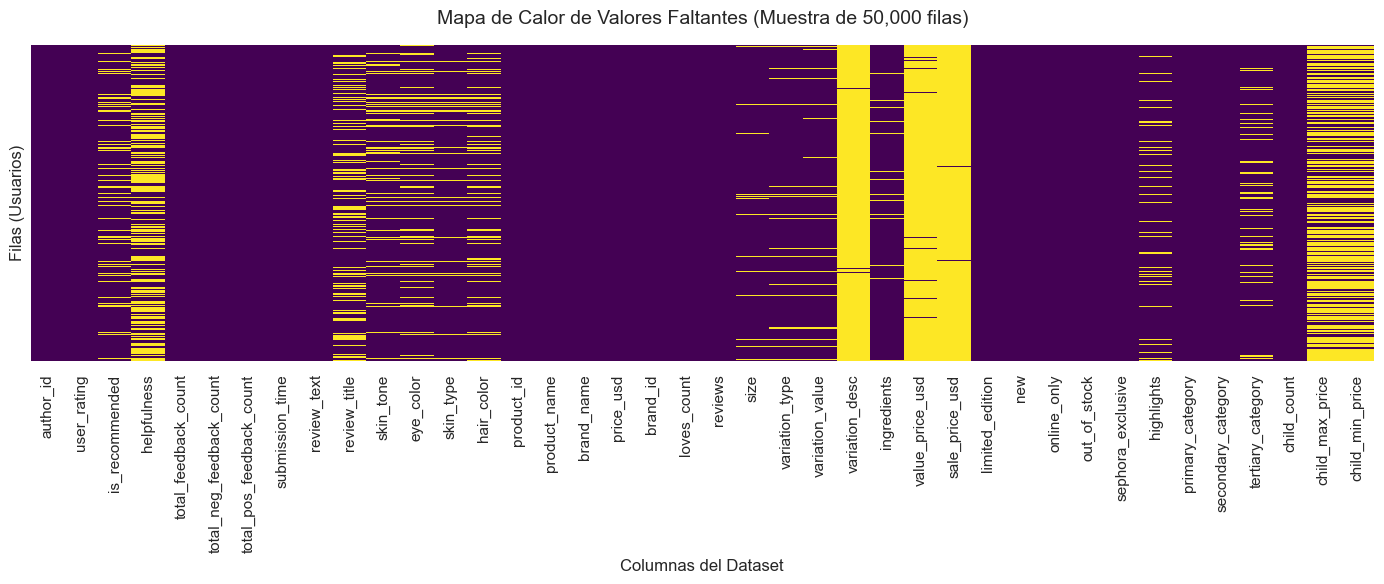

In [5]:
# Se genera un mapa de calor para visualizar la distribución de los valores faltantes en el dataset
print("Generando mapa de calor... (esto puede tomar unos segundos)")

# Se usa una muestra aleatoria de 50,000 filas para que el mapa de calor sea legible y no se sobrecargue visualmente
df_muestra = df_final.sample(n=50000, random_state=42)

plt.figure(figsize=(14, 6))
# Se visualizan los nulos
sns.heatmap(df_muestra.isna(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Mapa de Calor de Valores Faltantes (Muestra de 50,000 filas)', fontsize=14, pad=15)
plt.xlabel('Columnas del Dataset', fontsize=12)
plt.ylabel('Filas (Usuarios)', fontsize=12)
plt.tight_layout()
plt.show()

## Análisis de variables categóricas principales

### Análisis de Variables Categóricas

Al analizar la frecuencia de las categorías y las marcas en nuestro dataset, nuestro enfoque cambia: ya no medimos el tamaño del catálogo, sino **el volumen de participación de los clientes (engagement)**. 

De los gráficos generados se pudo extraer:

1. **Dominio de categorías:** Queda clarísimo que **Skincare** y **Makeup** son los que lideran en la plataforma, acaparando la inmensa mayoría de las reseñas.
2. **Liderazgo de marcas:** **CLINIQUE** domina por completo el análisis, seguida por **Tatcha**. Estas marcas han logrado que sus usuarios dejen comentarios masivamente.
3. **Limpieza de datos:** A diferencia de nuestro diagnóstico inicial en el catálogo, la variable `primary_category` presenta un formato limpio sin saltos de línea ocultos, lo que facilitará el trabajo en el Pipeline.

Top 10 Categorías con más reseñas:
primary_category
Skincare    1094411
Name: count, dtype: int64


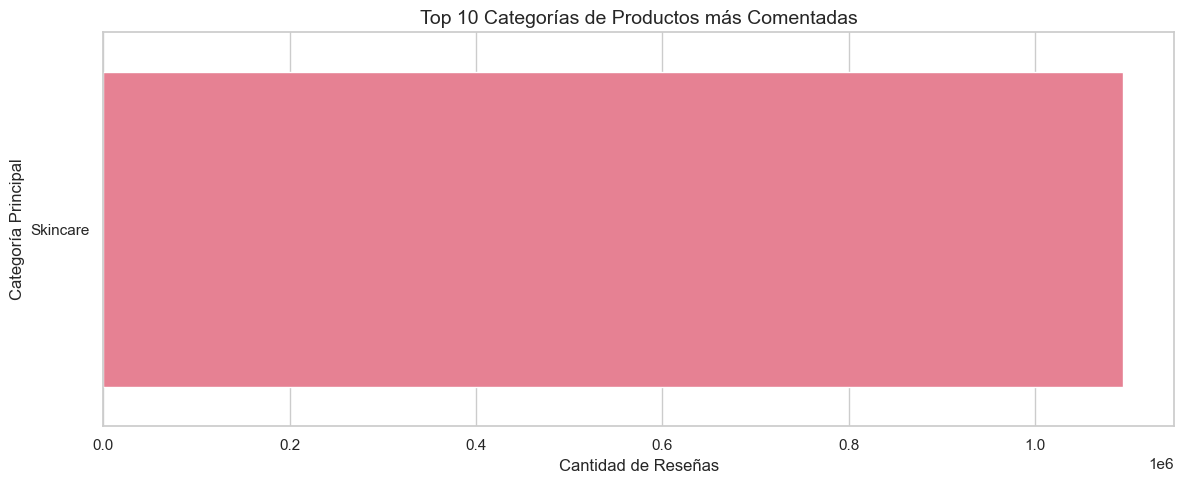



Top 10 Marcas con más reseñas:
brand_name
CLINIQUE               49029
Tatcha                 46770
Drunk Elephant         42395
fresh                  40886
The Ordinary           35934
Glow Recipe            31490
Youth To The People    29154
Origins                29063
Peter Thomas Roth      28846
LANEIGE                27519
Name: count, dtype: int64


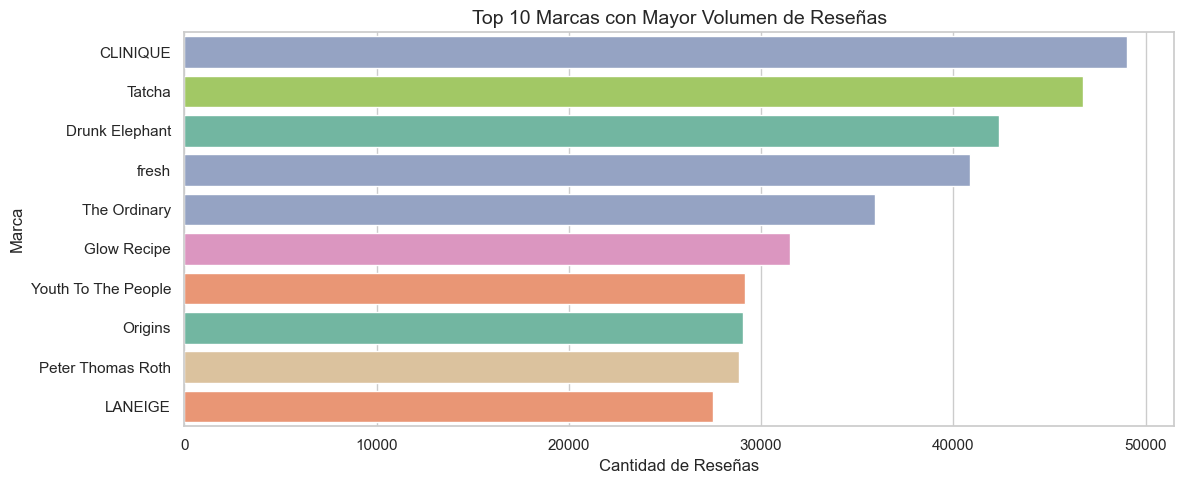

In [6]:
# Se exploran las categorías principales que generan más conversación entre los usuarios
print('Top 10 Categorías con más reseñas:')
print(df_final['primary_category'].value_counts().head(10)) 

plt.figure(figsize=(12, 5))
ax = sns.countplot(data=df_final, y='primary_category', 
                   order=df_final['primary_category'].value_counts().head(10).index, 
                   palette='husl', hue='primary_category', legend=False)
ax.set_title('Top 10 Categorías de Productos más Comentadas', fontsize=14)
ax.set_xlabel('Cantidad de Reseñas', fontsize=12)
ax.set_ylabel('Categoría Principal', fontsize=12)
plt.tight_layout()
plt.show()

# Separador visual
print('\n' + '='*50 + '\n')

# Se exploran las marcas más populares que generan más conversación entre los usuarios
print('Top 10 Marcas con más reseñas:')
print(df_final['brand_name'].value_counts().head(10))

plt.figure(figsize=(12, 5))
ax = sns.countplot(data=df_final, y='brand_name', 
                   order=df_final['brand_name'].value_counts().head(10).index, 
                   palette='Set2', hue='brand_name', legend=False)
ax.set_title('Top 10 Marcas con Mayor Volumen de Reseñas', fontsize=14)
ax.set_xlabel('Cantidad de Reseñas', fontsize=12)
ax.set_ylabel('Marca', fontsize=12)
plt.tight_layout()
plt.show()

## Análisis de distribución

### Análisis de Distribuciones Numéricas
Tras corregir los formatos de texto (como los precios) y eliminar las variables sin datos, los histogramas nos revelan el comportamiento real de nuestras variables:

1. **Tendencia Positiva en las Calificaciones (`user_rating`):** La distribución está fuertemente hacia la izquierda, con un pico en la calificación de 5 estrellas. Esto indica que los usuarios de Sephora tienden a dejar reseñas principalmente cuando están muy satisfechos con el producto.
2. **Distribución de Precios (`price_usd`, `value_price_usd`):** Los precios presentan una linea positiva (hacia la derecha). La gran concentración de productos se encuentra en un rango de precios bajos a medios, con una cola larga, que representa un grupo selecto de artículos de lujo de alto valor.
3. **Interacción y Viralidad (`helpfulness`, `loves_count`, `total_feedback_count`):** Estas variables de "engagement" muestran una caída extrema. La inmensa mayoría de las reseñas y productos reciben poca interacción o votos de utilidad, pero unos pocos logran volverse "virales", acumulando cientos o miles de interacciones.
4. **Filtro de Variables:** Cabe destacar que para este análisis de distribución continua se excluyeron las variables de identificación (IDs) y las variables binarias (ej. `is_recommended` o `online_only`), ya que al ser categoricas, deforma este tipo de visualización.

Variables numéricas continuas detectadas para graficar: ['user_rating', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd', 'loves_count', 'reviews', 'value_price_usd', 'sale_price_usd', 'child_count', 'child_max_price', 'child_min_price']


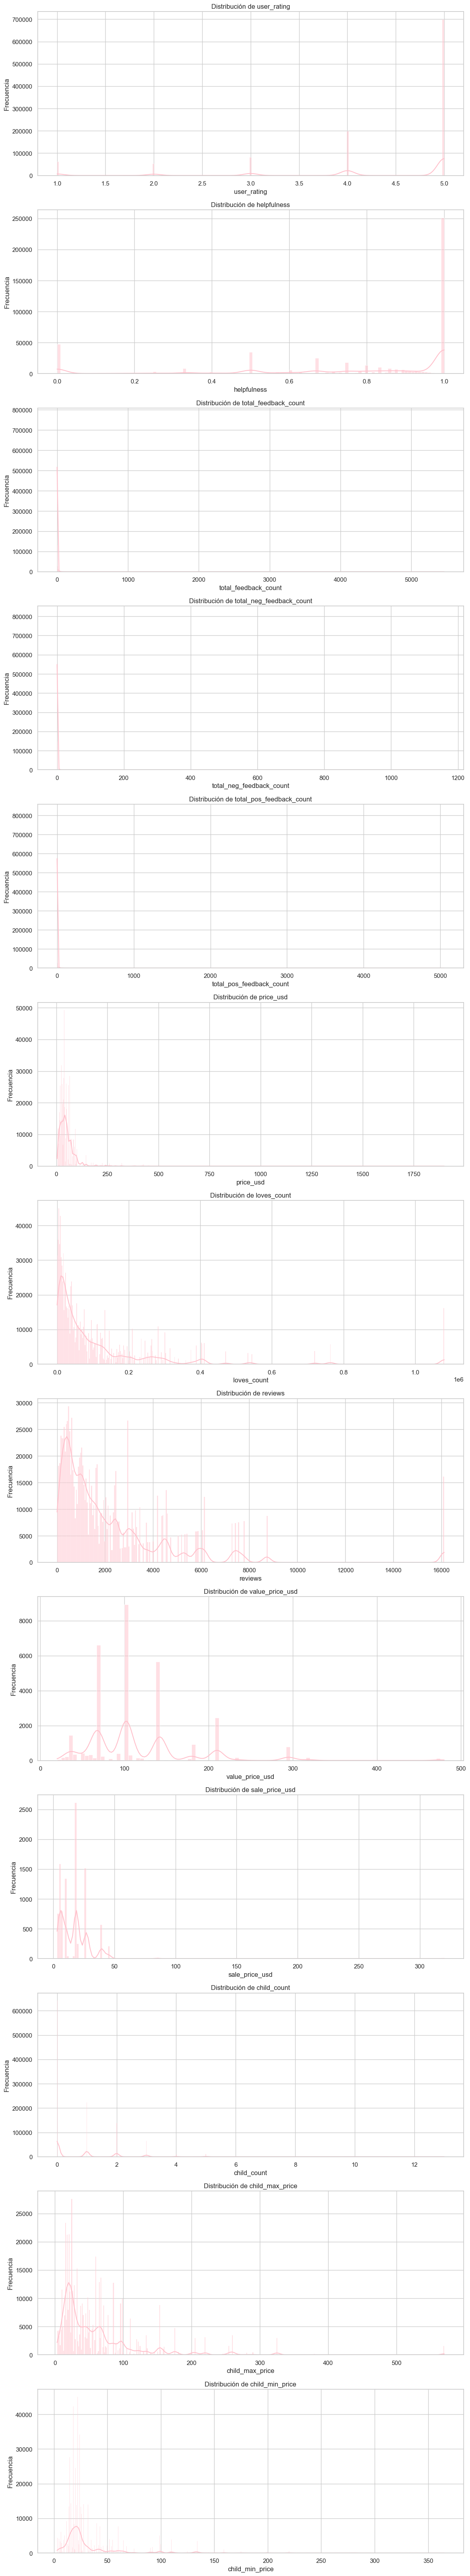

In [7]:
# Se filtran las columnas numéricas para analizar su distribución
numeric_cols = df_final.select_dtypes(include=['number']).columns.tolist() 

# Excluimos los IDs y las variables que son binarias (0 y 1) para no deformar los histogramas
columnas_a_excluir = [
    'author_id', 'product_id', 'brand_id', # IDs
    'is_recommended', 'limited_edition', 'new', 
    'online_only', 'out_of_stock', 'sephora_exclusive' # Binarias
]

numeric_cols = [col for col in numeric_cols if col not in columnas_a_excluir]

print('Variables numéricas continuas detectadas para graficar:', numeric_cols)

# Si hay variables numéricas, se gráfica
if numeric_cols:
    n_numeric = len(numeric_cols)
    fig, axs = plt.subplots(n_numeric, 1, figsize=(12, 5 * n_numeric), squeeze=False)
    axs = axs.flatten()
    
    for ax, col in zip(axs, numeric_cols):
        sns.histplot(data=df_final, x=col, kde=True, ax=ax, color='pink')
        ax.set_title(f'Distribución de {col}', fontsize=12)
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron variables numéricas válidas para el análisis.')

## Tratamientos de Outliers

### Tratamiento de Valores Atípicos (Outliers)

Durante el análisis de distribución, identificamos que varias de nuestras variables continuas (como los precios y las métricas de interacción) presentaban colas muy largas hacia la derecha, indicando la presencia de valores atípicos extremos.

Para preparar los datos para futuros modelos, hemos aplicado una técnica de **Capping basada en el Rango Intercuartílico (IQR)**. 

**Resultados Observados:**
* **Gráficos Rosados (Izquierda):** Muestran la distribución original con los outliers extendiéndose mucho más allá de los límites normales.
* **Gráficos Morados (Derecha):** Demuestran el éxito del Capping. La distribución se ha estabilizado sin perder una sola fila de información, creando un entorno más robusto para algoritmos sensibles a valores extremos.

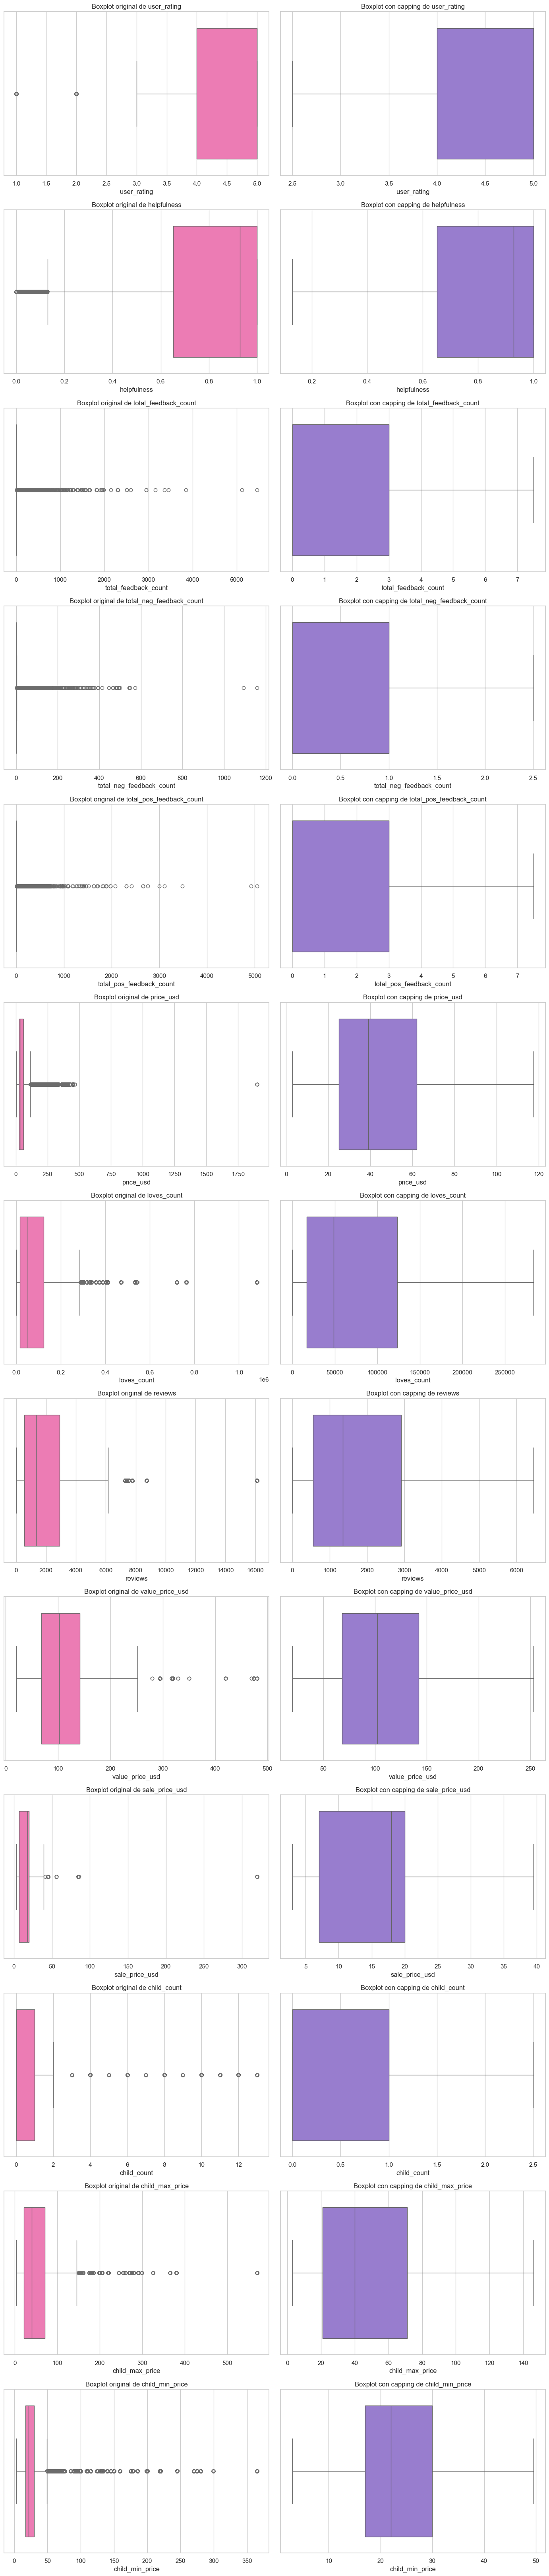

In [8]:
# Se utilizan las columnas de variables anteriores
cols_outliers = numeric_cols

# Se crea una copia del DataFrame para guardar los datos modificados
df_capped = df_final.copy() 

for col in cols_outliers: 
    # Se usa dropna() para que los nulos no rompan el cálculo
    q1 = df_final[col].dropna().quantile(0.25)
    q3 = df_final[col].dropna().quantile(0.75)
    iqr = q3 - q1 # Esta es la diferencia entre el tercer cuartil y el primer cuartil

    # Se definen los limites
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Se aplica el capping para limitar los valores sin eliminar registros
    df_capped[col] = df_final[col].clip(lower, upper)

# Se generan las visualizaciones para comparar el Antes y el Después
if cols_outliers:
    n_outliers = len(cols_outliers)
    fig, axs = plt.subplots(n_outliers, 2, figsize=(14, 5 * n_outliers), squeeze=False)
    for idx, col in enumerate(cols_outliers):
        # Gráfico de boxplot original (Datos crudos)
        sns.boxplot(data=df_final, x=col, ax=axs[idx, 0], color='hotpink')
        axs[idx, 0].set_title(f'Boxplot original de {col}')

        # Gráfico de boxplot con capping (Datos no crudos)
        sns.boxplot(data=df_capped, x=col, ax=axs[idx, 1], color='mediumpurple')
        axs[idx, 1].set_title(f'Boxplot con capping de {col}')

    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas numéricas disponibles para análisis de outliers.')

## Análisis de Correlación

### Análisis de Correlación

Tras aplicar la técnica de *Capping* a nuestros datos, hemos generado una matriz de correlación fuerte, libre de la distorsión que podrían causar los valores extremos (outliers). Los hallazgos más destacados de esta matriz son:

1. **La regla de la Popularidad (`loves_count` y `reviews`):**
   Existe una fuerte correlación positiva (**0.81**) entre la cantidad de reseñas y la cantidad de "Me encanta" que recibe un producto. Esto indica que el nivel de interacción es generalizado: los productos más vendidos/populares generan alto tráfico en todas las métricas de la plataforma a la misma vez.

2. **La Independencia de las Calificaciones (`user_rating`):**
   Uno de los descubrimientos más valiosos es que **la calificación de los usuarios no tiene correlación con el precio del producto**. Un producto de lujo no tiene garantizada una mejor calificación que un producto económico. Asimismo, la calificación es independiente de la cantidad de reseñas, los productos virales no son necesariamente los mejor evaluados.

3. **Métricas de Retroalimentación (`helpfulness` y `feedback_count`):**
   Como era de esperarse, existe una correlación casi perfecta entre el conteo total de feedback y el feedback positivo/negativo, lo cual valida la integridad matemática de las columnas del dataset.

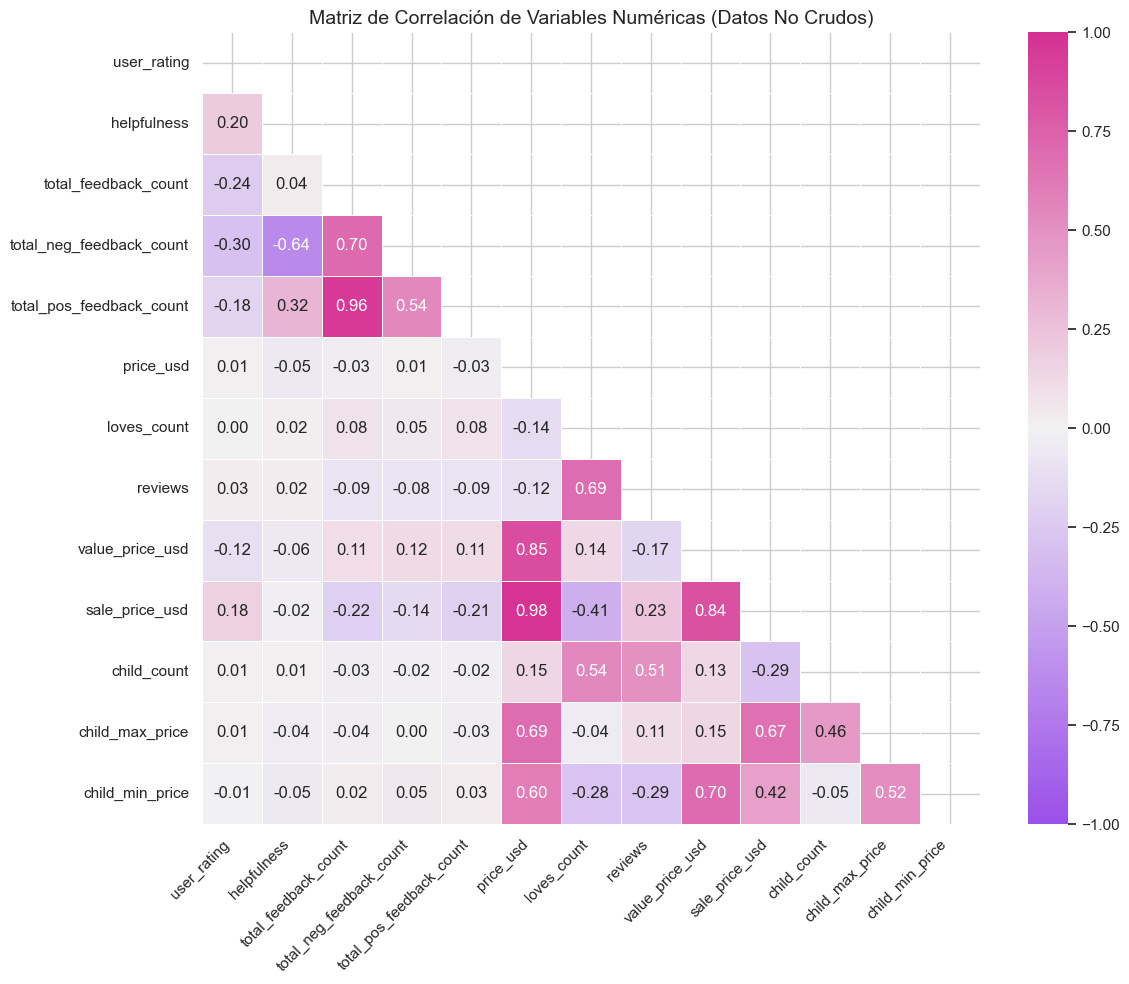

In [9]:
# Se verifican si existen variables numéricas para calcular la correlación
if numeric_cols:
    # Usamos df_capped, para que los outliers no distorsionen la correlación
    corr_matrix = df_capped[numeric_cols].corr()
    
    # Si la matriz de correlación está vacía, se avisa
    if corr_matrix.empty:
        print('No hay suficientes variables numéricas para calcular la matriz de correlación.')
    else:
        # Se crea una máscara para ocultar la mitad superior de la matriz (ya que es simétrica)
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        fig, ax = plt.subplots(figsize=(12, 10)) # Tamaño ajustado para mejor lectura
        
        # Se crea una paleta
        paleta_rosa_morado = sns.diverging_palette(280, 340, s=85, l=50, as_cmap=True)
        
        # Se genera un mapa de calor con nuestra paleta
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap=paleta_rosa_morado, fmt='.2f', 
                    linewidths=0.5, vmin=-1, vmax=1, ax=ax)
        
        ax.set_title('Matriz de Correlación de Variables Numéricas (Datos No Crudos)', fontsize=14)
        
        # Se ajustan las etiquetas para que se vean mejor
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        
        plt.tight_layout()
        plt.show()
else:
    print('No se encontraron variables numéricas para la matriz de correlación.')

## Conclusiones del Análisis Exploratorio y Diseño del Pipeline

Tras realizar el Análisis Exploratorio de Datos (EDA) sobre el dataset de Sephora, utilizamos este entorno para diagnosticar y validar las transformaciones que nuestros datos necesitan. Los hallazgos críticos son:

1. **Gestión de Nulos, Redundancias y Variables Inutilizables:**
   Al revisar la estructura del dataset, se identificaron varios problemas de integridad que deben ser tratados:
   * **Columnas con basura:** La variable `Unnamed: 0` es un índice arrastrado del archivo original y no aporta valor predictivo.
   * **Extrema falta de datos:** Variables como `variation_desc`, `sale_price_usd` y `value_price_usd` presentan más del 97% de valores nulos, estas deben ser descartadas.
   * **Redundancia por cruce de tablas:** Se detectaron variables duplicadas con sufijos `_x` e `_y` (ej. `price_usd_x` y `price_usd_y`, `brand_name_x` y `brand_name_y`). Se deberá seleccionar una única versión para evitar redundancia.

2. **Desafíos de Formato y Tipado (Dirty Data):**
   Descubrimos que la variable `price_usd` venía clasificada como texto debido al símbolo `$`. Al limpiarla manualmente durante el EDA, logramos desbloquear todo el análisis estadístico.

3. **Tratamiento de Valores Atípicos:**
   Validamos que aplicar el *Capping* mediante el IQR es la estrategia para variables de precio y métricas de interacción. Esto nos permitió estabilizar las distribuciones sin tener que eliminar productos premium o reseñas virales del dataset.

### Plan de Acción: Automatización mediante Pipeline de Preprocesamiento
Ahora que hemos validado manualmente qué transformaciones funcionan, el siguiente paso es **traspasarlo a un Pipeline** . Esto garantizará que cualquier nuevos datos crudos se limpien. El Pipeline ejecutará:

- **DropColumns Transformer:** Eliminación automatizada de variables con 100% de nulos o sin varianza.
- **PriceCleaner Transformer:** Extracción automatizada de valores numéricos en precios (limpieza de símbolos `$` y comas).
- **TextStripper:** Limpieza de saltos de línea y espacios en blanco accidentales en variables categóricas.
- **Imputer:** Estrategia de llenado para los valores nulos restantes.
- **Outlier Handler (Capping):** Aplicación de los límites IQR a las variables numéricas continuas para proteger los futuros modelos.